In [13]:
import os
import sys
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib import rcParams

In [14]:
#  r-reticulate env
adata = sc.read("/path/BMP4_YS_combined_integrate.h5ad")

/home/chengtao/miniconda2/envs/r-reticulate/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/home/chengtao/miniconda2/envs/r-reticulate/lib/python3.9/site-packages/anndata/compat/__init__.py:311: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


In [15]:
adata

AnnData object with n_obs × n_vars = 53570 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'RNA_snn_res.2', 'seurat_clusters', 'cell_types', 'percent.rb', 'RNA_snn_res.1', 'annotation', 'integrated_snn_res.1', 'integrated_snn_res.2', 'integrated_cell_type_all', 'cell_type_all_ordered', 'stage', 'stage_order'
    var: 'features'
    uns: 'neighbors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances'

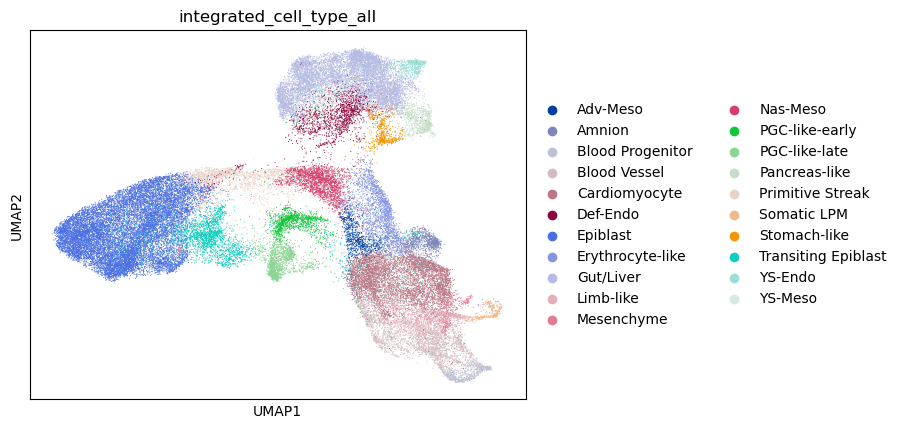

In [16]:
sc.pl.umap(adata,color='integrated_cell_type_all')

In [17]:
# first, store the old umap with a new name so it is not overwritten
adata.obsm['X_umap_old'] = adata.obsm['X_umap']

sc.pp.neighbors(adata, n_pcs = 30, n_neighbors = 20, use_rep="X_pca")
sc.tl.umap(adata, min_dist=0.4, spread=3)

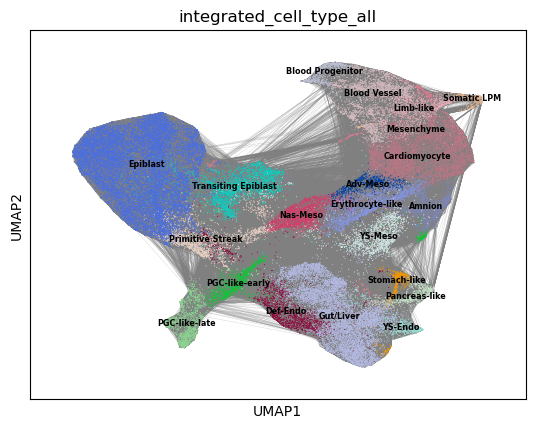

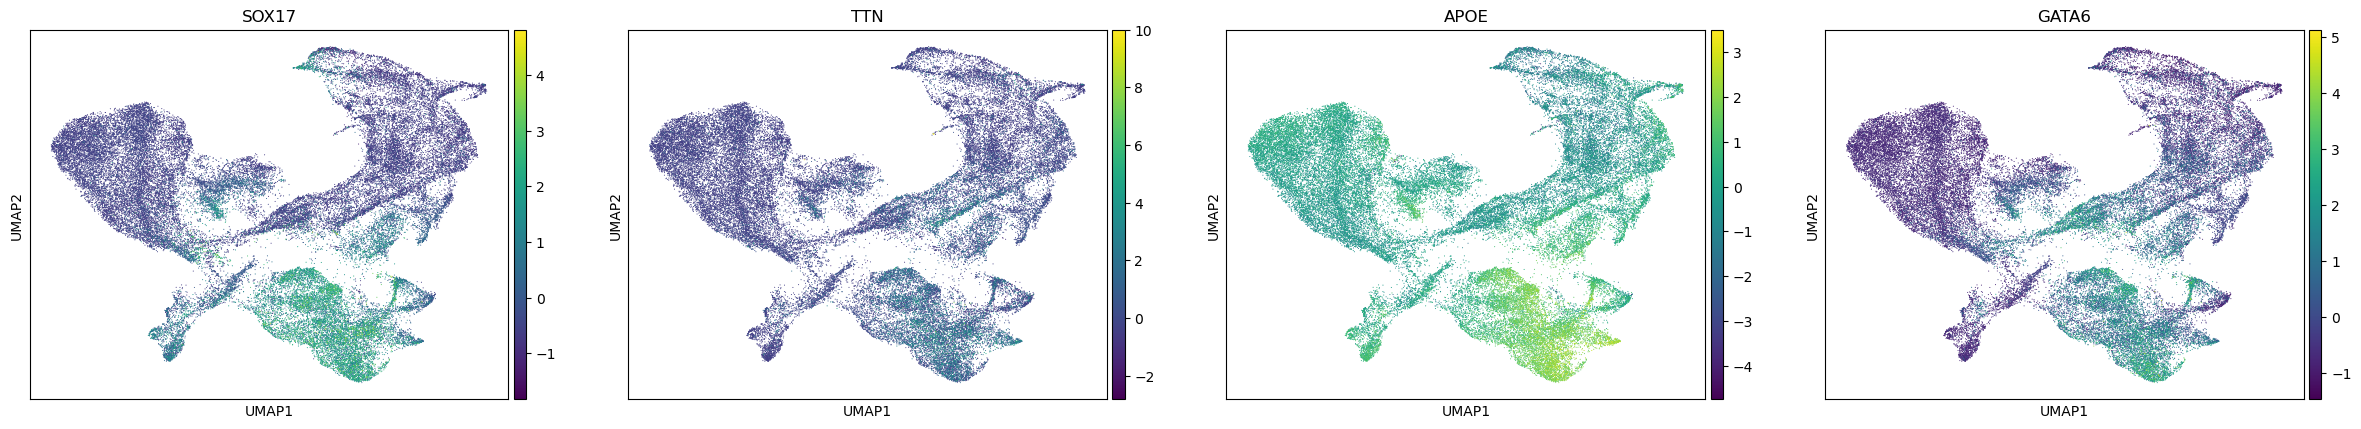

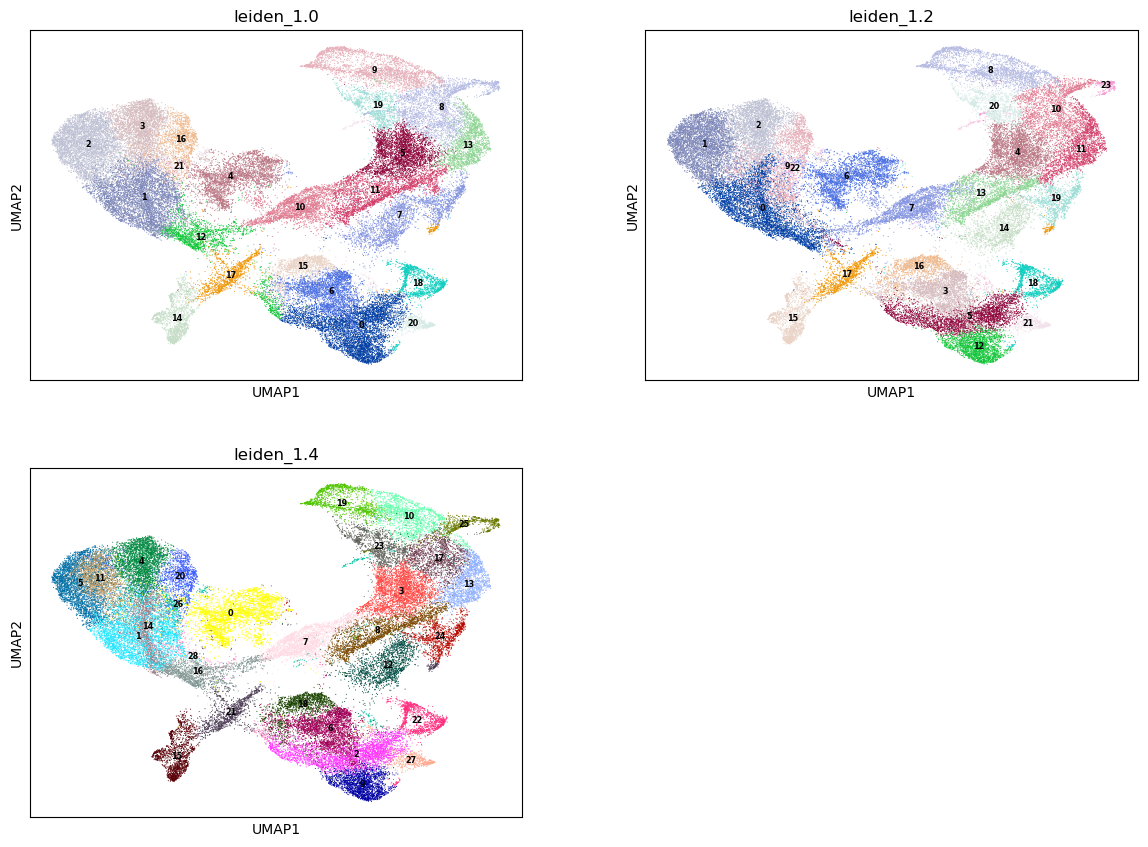

In [20]:
sc.pl.umap(adata, color = ['integrated_cell_type_all'],legend_loc = 'on data', legend_fontsize = 'xx-small', edges = True)

sc.pl.umap(adata, color = ['SOX17','TTN','APOE','GATA6'], use_raw = False, ncols = 4)

# Redo clustering as well
sc.tl.leiden(adata, key_added = "leiden_1.0", resolution = 1.0) # default resolution in 1.0
sc.tl.leiden(adata, key_added = "leiden_1.2", resolution = 1.2) # default resolution in 1.0
sc.tl.leiden(adata, key_added = "leiden_1.4", resolution = 1.4) # default resolution in 1.0

#sc.tl.louvain(adata, key_added = "leiden_1.0") # default resolution in 1.0
sc.pl.umap(adata, color = ['leiden_1.0', 'leiden_1.2', 'leiden_1.4'],legend_loc = 'on data', legend_fontsize = 'xx-small', ncols =2)

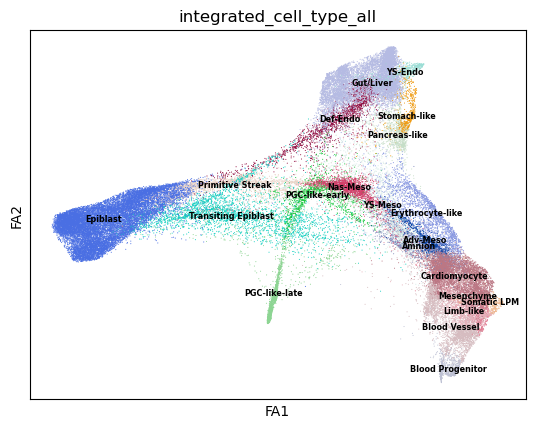

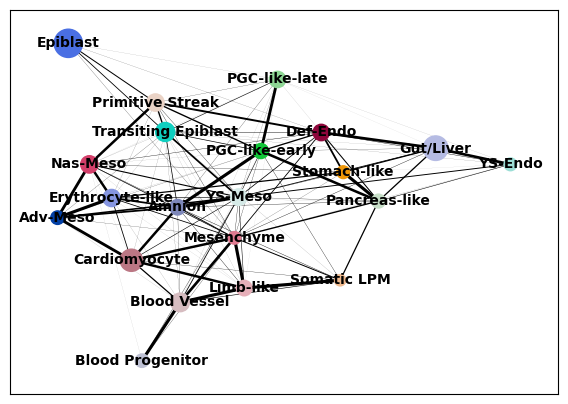

In [21]:
# use the umap to initialize the graph layout.
sc.tl.draw_graph(adata, init_pos='X_umap_old')
sc.pl.draw_graph(adata, color='integrated_cell_type_all', legend_loc='on data', legend_fontsize = 'xx-small')
sc.tl.paga(adata, groups='integrated_cell_type_all')
sc.pl.paga(adata, color='integrated_cell_type_all', edge_width_scale = 0.3)

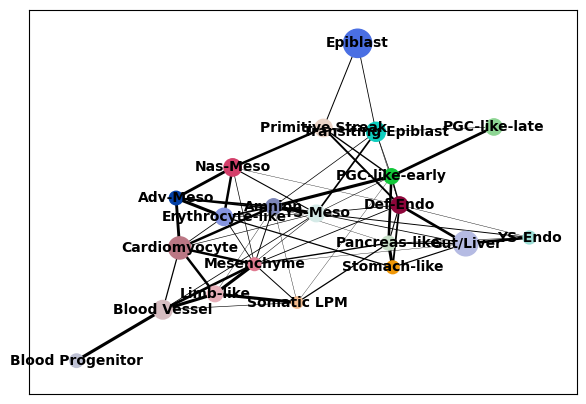

In [24]:
sc.pl.paga(adata, color='integrated_cell_type_all', edge_width_scale = 0.3,threshold=0.1,save='BMP4_YS_paga.pdf')

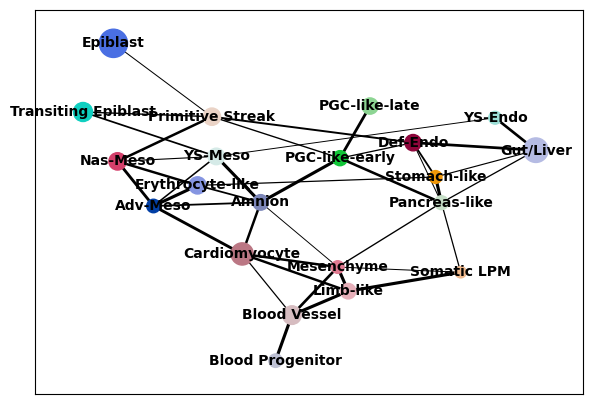

In [25]:
sc.pl.paga(adata, color='integrated_cell_type_all', edge_width_scale = 0.3,threshold=0.3)